# 1. 전처리

## 1-1-1. 중복 질문 개수 세기

In [ ]:
##중복된 질문 체크하고 중복된 것들 파일로 따로 저장하기

import pandas as pd

file = "[Ngolden]final_chatbot_results_fixed.xlsx"

try:
    df = pd.read_excel(file)
    # 컬럼명 정규화
    df.columns = [c.strip().lower() for c in df.columns]
    
    # 질문, 답변 컬럼 찾기
    q_col = next((c for c in df.columns if 'question' in c), None)
    a_col = next((c for c in df.columns if 'response' in c), None)
    
    if q_col and a_col:
        # 필요한 컬럼만 추출
        df_clean = df[[q_col, a_col]].copy()
        df_clean.columns = ['question', 'response']
        
        # 정확한 중복 확인을 위해 공백 제거
        df_clean['question'] = df_clean['question'].astype(str).str.strip()
        
        # 중복된 행 추출 (모든 중복 인스턴스 포함, keep=False)
        duplicates = df_clean[df_clean.duplicated(subset=['question'], keep=False)].sort_values(by='question')
        
        print(f"GQ 데이터셋 총 행 수: {len(df_clean)}")
        print(f"발견된 중복 행 수: {len(duplicates)}")
        
        if not duplicates.empty:
            # CSV 파일로 저장
            output_file = "duplicates_only.csv"
            duplicates.to_csv(output_file, index=False)
            print(f"✅ 중복 데이터가 '{output_file}' 파일로 저장되었습니다.")
            print("저장된 데이터 미리보기:")
            print(duplicates.head())
        else:
            print("중복된 질문이 없습니다.")
            
    else:
        print("질문 또는 답변 컬럼을 찾을 수 없습니다.")

except Exception as e:
    print(f"오류 발생: {e}")

GQ 데이터셋 총 행 수: 2755
발견된 중복 행 수: 499
✅ 중복 데이터가 'gq_duplicates_only.csv' 파일로 저장되었습니다.
저장된 데이터 미리보기:
                                      question  \
1793  Are Christians sinners, saints, or both?   
932   Are Christians sinners, saints, or both?   
276                           Can God save me?   
387                           Can God save me?   
371     Can a Christian “give back” salvation?   

                                               response  
1793  That’s a beautiful question. Christians are bo...  
932   That’s a beautiful question. In Christ, we’re ...  
276   Yes, God can save you. His grace is sufficient...  
387   Yes, God can save you. His grace is available ...  
371   This is a deeply personal and important questi...  


## 1-1-2. 중복 질문 첫번째만 남기고 전부 삭제하기

In [11]:
import pandas as pd

file = "[Ngolden]final_chatbot_results_fixed.xlsx"

# 1. 파일 불러오기
df = pd.read_excel(file)

# 2. 전처리 (컬럼명 및 질문 텍스트 공백 제거)
df.columns = [c.strip().lower() for c in df.columns]
q_col = next((c for c in df.columns if 'question' in c), None)

if q_col:
    df[q_col] = df[q_col].astype(str).str.strip()

    # 3. 중복 제거 (첫 번째 행만 유지)
    df_cleaned = df.drop_duplicates(subset=[q_col], keep='first')

    # 4. 저장
    df_cleaned.to_csv("[Ngolden]cleaned_final_chatbot_results_fixed.csv", index=False)
    
    print(f"제거된 중복 행: {len(df) - len(df_cleaned)}개")
    print(f"최종 남은 행: {len(df_cleaned)}개")

제거된 중복 행: 255개
최종 남은 행: 2500개


## 1-2-1. 에러 개수 체크

In [13]:
import pandas as pd

# 1. 파일 불러오기
file_path = '(중복제거)[Ngolden]cleaned_final_chatbot_results_fixed.csv'

try:
    df = pd.read_csv(file_path)

    # 2. 'routing' 컬럼이 실제로 존재하는지 확인
    if 'routing' in df.columns:
        
        # 3. 'routing' 컬럼에서 'error'라는 단어가 포함된 행 필터링
        error_mask = df['routing'].astype(str).str.contains('error', case=False, na=False)
        error_rows = df[error_mask]

        # 4. 결과 출력
        error_count = len(error_rows)
        
        print(f"총 데이터 개수: {len(df)}")
        print(f"routing 컬럼에 에러가 포함된 행의 개수: {error_count}")
        
        if error_count > 0:
            print("\n[에러가 발견된 행 예시 (상위 5개)]")
            print(error_rows.head())
            
            # 에러 행만 따로 저장하기
            output_file = "[golden]error_rows_only.xlsx"
            error_rows.to_excel(output_file, index=False)
            print(f"\n에러 행을 '{output_file}'로 저장했습니다.")
        else:
            print("\n에러가 발견되지 않았습니다.")

    else:
        print("오류: 엑셀 파일 내에 'routing'이라는 컬럼이 없습니다. 컬럼명을 확인해주세요.")

except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {file_path}")
except Exception as e:
    print(f"파일을 처리하는 중 오류가 발생했습니다: {e}")

총 데이터 개수: 2500
routing 컬럼에 에러가 포함된 행의 개수: 91

[에러가 발견된 행 예시 (상위 5개)]
    session_id                                           question routing  \
142      gq146  Could God create a rock so heavy He could not ...   ERROR   
143      gq147                    Does God have a sense of humor?   ERROR   
161      gq166            What is the baptism of the Holy Spirit?   ERROR   
213      gq218  What is the eternal procession of the Holy Spi...   ERROR   
215      gq220  What is the meaning ofperfectin 1 Corinthians ...   ERROR   

                                              response   status  
142  Recursion limit of 20 reached without hitting ...  Success  
143  Recursion limit of 20 reached without hitting ...  Success  
161  Recursion limit of 20 reached without hitting ...  Success  
213  Recursion limit of 20 reached without hitting ...  Success  
215  Recursion limit of 20 reached without hitting ...  Success  

에러 행을 '[golden]error_rows_only.xlsx'로 저장했습니다.


## 1-2-2. 두 파일 합쳤을 때 총 에러가 나서 지워야 하는 행 게수 새기

In [23]:
import pandas as pd

# 1. 파일 경로 설정
file_path1 = '[Golden]sample_result.csv'
file_path2 = '[NGolden]sample_result.csv'
output_filename = "error_comparison_result.csv"

try:
    # CSV 파일 읽기
    df1 = pd.read_csv(file_path1)
    df2 = pd.read_csv(file_path2)

    # 2. 'question' 기준으로 병합 (inner join)
    # suffixes=('_golden', '_ngolden') 덕분에 컬럼명이 자동으로 구분됩니다.
    merged_df = pd.merge(df1, df2, on='question', how='inner', suffixes=('_golden', '_ngolden'))

    print(f"병합된 전체 데이터 개수: {len(merged_df)}건")

    # 3. 에러 체크 함수 (대소문자 구분 없이 'error' 포함 여부)
    def check_error(text):
        return 'error' in str(text).lower()

    if 'routing_golden' in merged_df.columns and 'routing_ngolden' in merged_df.columns:
        
        # 각 컬럼에서 에러 여부 판별 (True/False)
        is_golden_error = merged_df['routing_golden'].apply(check_error)
        is_ngolden_error = merged_df['routing_ngolden'].apply(check_error)

        # 4. 에러 유형 분류
        # (1) 둘 다 에러
        both_error = is_golden_error & is_ngolden_error
        # (2) Golden만 에러
        only_golden_error = is_golden_error & (~is_ngolden_error)
        # (3) NGolden만 에러
        only_ngolden_error = (~is_golden_error) & is_ngolden_error
        
        # 'Analysis_Result' 컬럼 생성 (기본값 'Normal')
        merged_df['Analysis_Result'] = 'Normal'
        
        # 조건에 맞는 행에 태그 달기
        merged_df.loc[both_error, 'Analysis_Result'] = 'Both Error'
        merged_df.loc[only_golden_error, 'Analysis_Result'] = 'Only Golden Error'
        merged_df.loc[only_ngolden_error, 'Analysis_Result'] = 'Only NGolden Error'

        # ========================================================
        # [핵심] 5. 'Normal'(정상)인 행은 제외하고 에러 행만 남기기
        # ========================================================
        final_error_df = merged_df[merged_df['Analysis_Result'] != 'Normal']

        # 6. 보기 편하게 컬럼 순서 정리 (질문, 결과, 라우팅 정보 먼저 보이게)
        cols = ['question', 'Analysis_Result', 'routing_golden', 'routing_ngolden'] + \
               [c for c in final_error_df.columns if c not in ['question', 'Analysis_Result', 'routing_golden', 'routing_ngolden']]
        
        final_error_df = final_error_df[cols]
        
        # 7. 파일 저장
        final_error_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        # 결과 출력
        print("-" * 50)
        print(f"저장된 에러 데이터 개수 : {len(final_error_df)}건")
        print(f" - Both Error          : {both_error.sum()}건")
        print(f" - Only Golden Error   : {only_golden_error.sum()}건")
        print(f" - Only NGolden Error  : {only_ngolden_error.sum()}건")
        print("-" * 50)
        print(f"파일이 '{output_filename}' 이름으로 저장되었습니다.")
        
    else:
        print("오류: routing 컬럼을 찾을 수 없습니다.")

except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")
except Exception as e:
    print(f"오류 발생: {e}")

병합된 전체 데이터 개수: 322건
--------------------------------------------------
저장된 에러 데이터 개수 : 7건
 - Both Error          : 0건
 - Only Golden Error   : 3건
 - Only NGolden Error  : 4건
--------------------------------------------------
파일이 'error_comparison_result.csv' 이름으로 저장되었습니다.


## 1-2-2. 에러 행 지우기

# 파일 5개 모두 합치기
중복 제거 포함

In [25]:
import pandas as pd

# ---------------------------------------------------------
# 1. 파일 경로 설정
# ---------------------------------------------------------
file_golden_res = "[Golden]sample_result.csv"
file_ngolden_res = "[NGolden]sample_result.csv"

gt_configs = [
    {"path": "Book_Golden_Dataset.csv", "source": "book"},
    {"path": "GQ_Golden_Dataset.csv", "source": "gq"},
    {"path": "Whatsapp_Golden_Dataset.csv", "source": "whatsapp"}
]

# ---------------------------------------------------------
# 2. Ground Truth 로드 및 중복 제거 (기존 동일)
# ---------------------------------------------------------
dfs_gt = []
for config in gt_configs:
    try:
        df = pd.read_csv(config["path"])
        df.columns = [c.strip().lower() for c in df.columns]
        
        q_col = next((c for c in df.columns if 'question' in c), None)
        a_col = next((c for c in df.columns if 'answer' in c), None)
        
        if q_col and a_col:
            temp_df = df[[q_col, a_col]].copy()
            temp_df.columns = ['question', 'ground_truth']
            temp_df['source'] = config["source"]
            temp_df['question'] = temp_df['question'].astype(str).str.strip()
            temp_df = temp_df.drop_duplicates(subset=['question'], keep='first')
            dfs_gt.append(temp_df)
            print(f"[{config['source']}] 로드 완료: {len(temp_df)}개")
    except Exception as e:
        print(f"Error loading {config['path']}: {e}")

if dfs_gt:
    all_gt_df = pd.concat(dfs_gt, ignore_index=True)
    all_gt_df = all_gt_df.drop_duplicates(subset=['question'], keep='first')
    print(f"✅ Ground Truth 총 개수: {len(all_gt_df)}")
else:
    all_gt_df = pd.DataFrame(columns=['question', 'ground_truth', 'source'])
    print("⚠️ Ground Truth 데이터가 없습니다.")

# ---------------------------------------------------------
# 3. 챗봇 결과 파일 로드 함수 (컬럼명 소문자 변환 추가)
# ---------------------------------------------------------
def clean_and_load(file_path, name):
    try:
        df = pd.read_csv(file_path)
        # 컬럼명 공백 제거 및 소문자 변환 (KeyError 방지)
        df.columns = [c.strip().lower() for c in df.columns]
        
        if 'question' in df.columns:
            df['question'] = df['question'].astype(str).str.strip()
            before = len(df)
            df = df.drop_duplicates(subset=['question'], keep='first')
            after = len(df)
            print(f"[{name}] 중복 제거: {before} -> {after} ({before-after}개 삭제됨)")
            return df
        return df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

df_gold = clean_and_load(file_golden_res, "Golden Result")
df_ngold = clean_and_load(file_ngolden_res, "NGolden Result")

# ---------------------------------------------------------
# 4. 컬럼명 표준화 및 병합 (수정된 핵심 파트)
# ---------------------------------------------------------

# (1) 컬럼 이름 표준화 함수
# 파일에 'response'가 있을 수도, 이미 'response_golden'일 수도 있음을 처리
def standardize_columns(df, suffix):
    # response -> response_{suffix}
    if 'response' in df.columns:
        df = df.rename(columns={'response': f'response_{suffix}'})
    
    # routing -> routing_{suffix}
    if 'routing' in df.columns:
        df = df.rename(columns={'routing': f'routing_{suffix}'})
        
    return df

# 컬럼 이름 변경 적용
df_gold = standardize_columns(df_gold, 'golden')
df_ngold = standardize_columns(df_ngold, 'ngolden')

# (2) 필요한 컬럼만 선택 (KeyError 방지를 위해 컬럼 존재 여부 확인)
# 이제 컬럼명은 무조건 response_golden, routing_golden 형태라고 가정하거나 확인함
cols_gold = ['session_id', 'question', 'response_golden', 'routing_golden']
cols_ngold = ['session_id', 'response_ngolden', 'routing_ngolden']

# 실제 데이터프레임에 있는 컬럼만 골라내기 (교집합)
sel_cols_gold = [c for c in cols_gold if c in df_gold.columns]
sel_cols_ngold = [c for c in cols_ngold if c in df_ngold.columns]

df_gold_sub = df_gold[sel_cols_gold]
df_ngold_sub = df_ngold[sel_cols_ngold]

# (3) Chatbot 결과 합치기 (session_id 기준)
# session_id가 양쪽에 다 있어야 병합 가능
merged_res = pd.merge(df_gold_sub, df_ngold_sub, on='session_id', how='inner')
print(f"챗봇 결과 병합 완료: {len(merged_res)}건")

# (4) 🔥 에러 행 삭제 로직 (routing 컬럼 검사)
def has_error(row):
    # 컬럼이 없을 경우를 대비해 get 사용 (없으면 빈 문자열)
    r_gold = str(row.get('routing_golden', '')).lower()
    r_ngold = str(row.get('routing_ngolden', '')).lower()
    
    # 두 컬럼 중 하나라도 'error'가 포함되면 True
    return ('error' in r_gold) or ('error' in r_ngold)

# 에러가 있는 행 찾기
error_mask = merged_res.apply(has_error, axis=1)
error_count = error_mask.sum()

# 에러가 *없는* 행만 남기기 (~)
merged_res_clean = merged_res[~error_mask].copy()

print(f"❌ 발견된 에러 행 개수: {error_count}개 (삭제됨)")
print(f"✨ 에러 제거 후 남은 데이터: {len(merged_res_clean)}건")

# (5) Ground Truth와 합치기 (question 기준)
final_df = pd.merge(merged_res_clean, all_gt_df, on='question', how='inner')

# ---------------------------------------------------------
# 5. 최종 컬럼 정리 및 저장
# ---------------------------------------------------------
# routing 컬럼은 필터링 용도였으므로 최종 결과에서는 제외하고 싶다면 아래 리스트 사용
target_columns = [
    'session_id', 'question', 
    'response_golden', 'response_ngolden', 
    'ground_truth', 'source'
]

# 최종 데이터프레임에 존재하는 컬럼만 선택
final_cols = [c for c in target_columns if c in final_df.columns]
final_df = final_df[final_cols]

print(f"\n🎉 최종 데이터셋 크기: {final_df.shape}")
# print("최종 컬럼:", final_df.columns.tolist())

output_file = "final_dataset_fully_cleaned.csv"
final_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"파일 저장 완료: {output_file}")

[book] 로드 완료: 779개
[gq] 로드 완료: 1614개
[whatsapp] 로드 완료: 114개
✅ Ground Truth 총 개수: 2500
[Golden Result] 중복 제거: 322 -> 322 (0개 삭제됨)
[NGolden Result] 중복 제거: 322 -> 322 (0개 삭제됨)
챗봇 결과 병합 완료: 322건
❌ 발견된 에러 행 개수: 7개 (삭제됨)
✨ 에러 제거 후 남은 데이터: 315건

🎉 최종 데이터셋 크기: (315, 6)
파일 저장 완료: final_dataset_fully_cleaned.csv


# 1. 전체 평가
bert 모델로 코사인 유사도 구하기

평가 대상 데이터 개수: 315개
모델 로딩 중...

[1/2] Golden 답변 평가 중...
임베딩 생성 중...


Batches: 100%|██████████| 10/10 [00:01<00:00,  7.65it/s]


유사도 계산 중...

[2/2] NGolden 답변 평가 중...
임베딩 생성 중...


Batches: 100%|██████████| 10/10 [00:01<00:00,  7.71it/s]

유사도 계산 중...

📊 최종 평가 결과
✅ Golden 평균 유사도  : 0.7299
❌ NGolden 평균 유사도 : 0.7274
📈 성능 향상률        : 0.34%

[Source별 성능 비교]
          score_golden  score_ngolden
source                               
book          0.761235       0.768915
gq            0.753566       0.745966
whatsapp      0.663409       0.661475


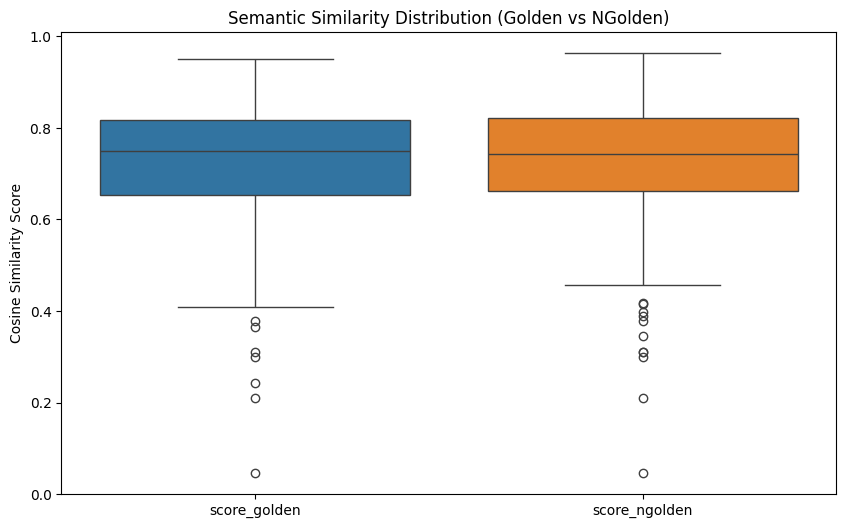


💾 평가 결과가 'final_evaluation_results.csv'에 저장되었습니다.


In [26]:

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
file_path = "final_dataset_fully_cleaned.csv"
df = pd.read_csv(file_path)

# 혹시 모를 결측치 제거 (텍스트가 비어있으면 에러 발생)
df = df.dropna(subset=['ground_truth', 'response_golden', 'response_ngolden'])
print(f"평가 대상 데이터 개수: {len(df)}개")

# 2. 모델 로드 (가볍고 성능 좋은 모델: all-MiniLM-L6-v2)
print("모델 로딩 중...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. 유사도 계산 함수
def calculate_similarity_batch(ground_truths, candidates):
    # 임베딩 생성 (Batch 처리로 속도 향상)
    print("임베딩 생성 중...")
    gt_embeddings = model.encode(ground_truths.tolist(), show_progress_bar=True)
    cand_embeddings = model.encode(candidates.tolist(), show_progress_bar=True)
    
    # 코사인 유사도 계산
    print("유사도 계산 중...")
    similarities = []
    for gt, cand in zip(gt_embeddings, cand_embeddings):
        sim = cosine_similarity(gt.reshape(1, -1), cand.reshape(1, -1))[0][0]
        similarities.append(sim)
    
    return similarities

# 4. 평가 실행
print("\n[1/2] Golden 답변 평가 중...")
df['score_golden'] = calculate_similarity_batch(df['ground_truth'], df['response_golden'])

print("\n[2/2] NGolden 답변 평가 중...")
df['score_ngolden'] = calculate_similarity_batch(df['ground_truth'], df['response_ngolden'])

# 5. 결과 분석 및 출력
mean_golden = np.mean(df['score_golden'])
mean_ngolden = np.mean(df['score_ngolden'])
improvement = (mean_golden - mean_ngolden) / mean_ngolden * 100

print("\n" + "="*50)
print(f"📊 최종 평가 결과")
print("="*50)
print(f"✅ Golden 평균 유사도  : {mean_golden:.4f}")
print(f"❌ NGolden 평균 유사도 : {mean_ngolden:.4f}")
print(f"📈 성능 향상률        : {improvement:.2f}%")

# 소스별 분석 (어떤 데이터셋에서 가장 효과가 좋았는지)
print("\n[Source별 성능 비교]")
print(df.groupby('source')[['score_golden', 'score_ngolden']].mean())

# 6. 시각화 (논문용 그래프)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['score_golden', 'score_ngolden']])
plt.title('Semantic Similarity Distribution (Golden vs NGolden)')
plt.ylabel('Cosine Similarity Score')
plt.show()

# 결과 파일 저장
df.to_csv("final_evaluation_results.csv", index=False)
print("\n💾 평가 결과가 'final_evaluation_results.csv'에 저장되었습니다.")

In [27]:
# 점수 차이 계산
df['score_diff'] = df['score_ngolden'] - df['score_golden']

# NGolden이 훨씬 못한 경우 (점수가 0.05 이상 떨어진 경우)
worse_cases = df[df['score_diff'] < -0.05].sort_values('score_diff')

print("NGolden이 더 안 좋은 답변 상위 5개:")
print(worse_cases[['question', 'ground_truth', 'response_golden', 'response_ngolden', 'score_diff']].head())

NGolden이 더 안 좋은 답변 상위 5개:
                                              question  \
156      What is the biblical view of white privilege?   
9    How is it possible to accept a servant and mes...   
144         Does a wife have to submit to her husband?   
233                         Who was Seth in the Bible?   
17   Where is the central authority/headquarters of...   

                                          ground_truth  \
156  The Bible doesn't mention "white privilege" di...   
9    It's understandable to have questions about th...   
144  In a Christian marriage, the idea of a wife su...   
233  Seth was the third son of Adam and Eve, born a...   
17   The Christian faith doesn't have a single cent...   

                                       response_golden  \
156  The Bible teaches that all people are equal in...   
9    The Bible teaches that Jesus is both fully hum...   
144  The question of a wife submitting to her husba...   
233  Seth is a significant figure in the ear

### Whatsapp 코사인 유사도가 작아진 이유 분석

In [29]:
import pandas as pd

# 1. 평가 결과 파일 로드 (아까 만든 파일이 있다면 그것 사용, 없으면 다시 계산)
# 편의상 'all_combined_cleaned.csv'를 다시 로드해서 유사도 계산 후 분석
df = pd.read_csv("final_dataset_fully_cleaned.csv")

# Whatsapp 데이터만 필터링
df_whatsapp = df[df['source'] == 'whatsapp'].copy()

# (임시) 유사도 점수가 없다면 TF-IDF로 빠르게 다시 계산
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances

tfidf = TfidfVectorizer().fit(pd.concat([df['ground_truth'], df['response_golden'], df['response_ngolden']]))
emb_gt = tfidf.transform(df_whatsapp['ground_truth'])
emb_gold = tfidf.transform(df_whatsapp['response_golden'])
emb_ngold = tfidf.transform(df_whatsapp['response_ngolden'])

# 유사도 계산 (1 - distance)
df_whatsapp['score_golden'] = 1 - paired_cosine_distances(emb_gt, emb_gold)
df_whatsapp['score_ngolden'] = 1 - paired_cosine_distances(emb_gt, emb_ngold)

# 2. "Golden이 점수가 떨어진 경우"만 추출 (역설적 분석)
# 점수가 떨어졌는데 내용은 더 좋을 수 있습니다.
worse_cases = df_whatsapp[df_whatsapp['score_golden'] < df_whatsapp['score_ngolden']].copy()
worse_cases['diff'] = worse_cases['score_ngolden'] - worse_cases['score_golden']

# 차이가 큰 순서대로 정렬
worse_cases = worse_cases.sort_values(by='diff', ascending=False)

print(f"Whatsapp 총 데이터: {len(df_whatsapp)}개")
print(f"Golden 점수가 더 낮은 케이스: {len(worse_cases)}개")

# 3. 눈으로 확인하기 (상위 3개 출력)
pd.set_option('display.max_colwidth', None) # 전체 텍스트 보기

for index, row in worse_cases.head(3).iterrows():
    print("\n" + "="*80)
    print(f"🔴 [Question]: {row['question']}")
    print(f"🟢 [Ground Truth (정답)]: {row['ground_truth']}")
    print("-" * 40)
    print(f"❌ [NGolden 답변 (점수 높음: {row['score_ngolden']:.4f})]: {row['response_ngolden']}")
    print("-" * 40)
    print(f"✅ [Golden 답변 (점수 낮음: {row['score_golden']:.4f})]: {row['response_golden']}")
    print("="*80)

Whatsapp 총 데이터: 89개
Golden 점수가 더 낮은 케이스: 45개

🔴 [Question]: Hello. Can I ask you a few questions about Jesus Christ? I have a Bible, but it is more than 300 years old.
🟢 [Ground Truth (정답)]: Of course! I'd be happy to help with any questions you have about Jesus. A 300-year-old Bible sounds like a wonderful treasure. Feel free to ask anything, and I'll do my best to provide guidance.
----------------------------------------
❌ [NGolden 답변 (점수 높음: 0.4834)]: Hello! It’s wonderful that you have an old Bible—what a treasure. I’d be honored to help you explore questions about Jesus. What would you like to know? Feel free to ask anything that’s on your heart.
----------------------------------------
✅ [Golden 답변 (점수 낮음: 0.1372)]: I see you have a very old Bible and are interested in discussing its teachings or historical context related to Jesus Christ. What specific questions or topics would you like to explore about Jesus or the historical background of your Bible? I’m here to help you conn

=> 에러 때문에 점수 낮아짐  ..

## RAGAS로 평가

In [ ]:
import os
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import answer_correctness, answer_similarity
from langchain_upstage import ChatUpstage, UpstageEmbeddings
from tqdm.auto import tqdm
from dotenv import load_dotenv

load_dotenv()

# ---------------------------------------------------------
# 1. 모델 설정
# ---------------------------------------------------------
# API 키가 환경변수에 없으면 .env 파일 확인 필요
upstage_llm = ChatUpstage(model="solar-pro") 
upstage_embeddings = UpstageEmbeddings(model="solar-embedding-1-large")

# ---------------------------------------------------------
# 2. 데이터 전처리 함수 (리스트 괄호 제거 수정 유지)
# ---------------------------------------------------------
df = pd.read_csv("final_dataset_fully_cleaned.csv")

def prepare_ragas_data(subset_df, answer_col):
    data = {
        'question': subset_df['question'].astype(str).tolist(),
        'answer': subset_df[answer_col].astype(str).tolist(),
        # [중요] Ragas 최신 버전 호환을 위해 리스트([])가 아닌 단일 문자열로 변환
        'ground_truth': subset_df['ground_truth'].astype(str).tolist() 
    }
    return Dataset.from_dict(data)

# ---------------------------------------------------------
# 3. 배치 평가 실행 함수
# ---------------------------------------------------------
def run_evaluation_with_progress(full_df, answer_col, metrics, llm, embeddings, batch_size=10):
    all_results = []
    total_rows = len(full_df)
    
    print(f"🚀 총 {total_rows}개 데이터를 {batch_size}개씩 나누어 평가합니다...")
    
    for i in tqdm(range(0, total_rows, batch_size), desc=f"Evaluating [{answer_col}]"):
        batch_df = full_df.iloc[i : i + batch_size].copy()
        dataset_batch = prepare_ragas_data(batch_df, answer_col)
        
        try:
            batch_result = evaluate(
                dataset_batch,
                metrics=metrics,
                llm=llm,
                embeddings=embeddings,
                raise_exceptions=False 
            )
            res_df = batch_result.to_pandas()
            if not res_df.empty:
                all_results.append(res_df)
            
        except Exception as e:
            print(f"⚠️ Error in batch {i//batch_size}: {e}")
            continue

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    else:
        return pd.DataFrame()

# ---------------------------------------------------------
# 4. 실행 (핵심 수정: Relevancy 제거)
# ---------------------------------------------------------
# 🔥 속도 향상을 위해 answer_relevancy 제거함
metrics = [answer_correctness, answer_similarity]

# (1) Golden 평가
print("\n============== [1/2] Golden 답변 평가 시작 ==============")
df_res_gold = run_evaluation_with_progress(
    df, 'response_golden', metrics, upstage_llm, upstage_embeddings
)

# (2) NGolden 평가
print("\n============== [2/2] NGolden 답변 평가 시작 ==============")
df_res_ngold = run_evaluation_with_progress(
    df, 'response_ngolden', metrics, upstage_llm, upstage_embeddings
)

# ---------------------------------------------------------
# 5. 결과 출력 및 저장
# ---------------------------------------------------------
print("\n" + "="*50)
print("📊 Ragas x Upstage 평가 결과 (Average Score)")
print("="*50)

if not df_res_gold.empty and not df_res_ngold.empty:
    # 평균 점수 계산 (Relevancy 제외)
    g_correct = df_res_gold['answer_correctness'].mean()
    n_correct = df_res_ngold['answer_correctness'].mean()
    
    g_sim = df_res_gold['answer_similarity'].mean()
    n_sim = df_res_ngold['answer_similarity'].mean()
    
    print(f"{'Metric':<25} | {'Golden':<10} | {'NGolden':<10}")
    print("-" * 50)
    print(f"{'Answer Correctness':<25} | {g_correct:.4f}     | {n_correct:.4f}")
    print(f"{'Answer Similarity':<25} | {g_sim:.4f}     | {n_sim:.4f}")
    
    # 원본 DF에 점수 저장
    df['golden_correctness'] = df_res_gold['answer_correctness']
    df['ngolden_correctness'] = df_res_ngold['answer_correctness']
    
    # Similarity 점수도 저장 (분석용)
    df['golden_similarity'] = df_res_gold['answer_similarity']
    df['ngolden_similarity'] = df_res_ngold['answer_similarity']
    
    # 파일 저장
    output_filename = "ragas_upstage_result_fast.csv"
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print("-" * 50)
    print(f"✅ 모든 평가 완료! 결과 파일 저장됨: {output_filename}")
else:
    print("❌ 평가 결과가 비어있습니다. 에러 로그를 확인하세요.")

/Users/dayoung/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



============== [1/2] Golden 답변 평가 시작 ==============
🚀 총 315개 데이터를 10개씩 나누어 평가합니다...


Evaluating [response_golden]: 100%|██████████| 32/32 [40:38<00:00, 76.19s/it]



============== [2/2] NGolden 답변 평가 시작 ==============
🚀 총 315개 데이터를 10개씩 나누어 평가합니다...


Evaluating [response_ngolden]:  56%|█████▋    | 18/32 [23:14<18:07, 77.66s/it]Exception raised in Job[14]: OutputParserException(Invalid json output: {
    "TP": [
        {
            "statement": "Scripture reminds humans that God’s plans unfold perfectly, even when humans cannot see the full picture.",
            "reason": "This aligns with the ground truth statements 'God's timing is always perfect, even if it does not match human schedules' and 'In His perfect time, God strengthens and guides humans.'"
        },
        {
            "statement": "Humans should trust that God is working behind the scenes for their good (Romans 8:28).",
            "reason": "This is supported by the ground truth statement 'Even in trials, humans can find comfort knowing that God is at work' and 'God orchestrates everything for human good and His divine purpose.'"
        },
        {
            "statement": "Humans should pray for patience.",
            "reason": "This is directly supported b


📊 Ragas x Upstage 평가 결과 (Average Score)
Metric                    | Golden     | NGolden   
--------------------------------------------------
Answer Correctness        | 0.6608     | 0.6600
Answer Similarity         | 0.7955     | 0.7965
--------------------------------------------------
✅ 모든 평가 완료! 결과 파일 저장됨: ragas_upstage_result_fast.csv


In [2]:
import pandas as pd

# 1. 결과 파일 로드
df = pd.read_csv("ragas_upstage_result_fast.csv")

# 2. 점수 차이 계산 (Golden - NGolden)
# 양수면 Golden이 더 잘한 것, 음수면 NGolden이 더 잘한 것
df['correctness_gap'] = df['golden_correctness'] - df['ngolden_correctness']

# 3. Golden이 '압도적으로' 이긴 케이스 (차이가 0.2 이상)
golden_wins = df[df['correctness_gap'] >= 0.2].sort_values(by='correctness_gap', ascending=False)

# 4. NGolden이 의외로 이긴 케이스 (차이가 -0.2 이하)
ngolden_wins = df[df['correctness_gap'] <= -0.2].sort_values(by='correctness_gap', ascending=True)

# 5. 출력
print(f"🏆 Golden이 확실히 더 잘한 건수: {len(golden_wins)}개")
print(f"⚠️ NGolden이 더 잘한 건수: {len(ngolden_wins)}개")

print("\n" + "="*50)
print("🔍 [Case 1] Golden이 압도적으로 이긴 질문 TOP 3")
print("="*50)
for i, row in golden_wins.head(3).iterrows():
    print(f"Q: {row['question']}")
    print(f"👍 Golden ({row['golden_correctness']:.2f}): {row['response_golden'][:100]}...")
    print(f"👎 NGolden ({row['ngolden_correctness']:.2f}): {row['response_ngolden'][:100]}...")
    print(f"🎯 Ground Truth: {row['ground_truth'][:100]}...")
    print("-" * 30)

print("\n" + "="*50)
print("🔍 [Case 2] NGolden이 더 점수가 높은 질문 TOP 3 (왜일까?)")
print("="*50)
for i, row in ngolden_wins.head(3).iterrows():
    print(f"Q: {row['question']}")
    print(f"👎 Golden ({row['golden_correctness']:.2f}): {row['response_golden'][:100]}...")
    print(f"👍 NGolden ({row['ngolden_correctness']:.2f}): {row['response_ngolden'][:100]}...")
    print(f"🎯 Ground Truth: {row['ground_truth'][:100]}...")
    print("-" * 30)

🏆 Golden이 확실히 더 잘한 건수: 12개
⚠️ NGolden이 더 잘한 건수: 14개

🔍 [Case 1] Golden이 압도적으로 이긴 질문 TOP 3
Q: If both Muhammad and Christ were prophets chosen by God, why did God not choose only one prophet?
👍 Golden (0.59): The Bible teaches that God’s plan unfolds through many prophets over time to reveal His truth progre...
👎 NGolden (0.15): The question of why God sent multiple prophets instead of one is rooted in the idea that different t...
🎯 Ground Truth: In Christian theology, Jesus Christ is seen as the Son of God and the Savior, not merely a prophet. ...
------------------------------
Q: 1.  Is the Islamic Prophet Muhammad (PBUH) mentioned in your Gospel as the final prophet? 2. Hasn't the Christian religion been superseded by the coming of the final prophet, Muhammad Mustafa? Please answer with correct and reliable reasons.
👍 Golden (0.95): Thank you for sharing your perspective. It is clear that both Islam and Christianity hold deep rever...
👎 NGolden (0.53): Thank you for sharing your thou